In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report)

In [2]:
# 1. Dataset Loading and Preprocessing
iris = load_iris()
X,y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Split dataset (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [3]:
# Scaling for faster convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# 2. Default Logistic Regression Model
# 'lbfgs' is the default solver in scikit-learn
default_lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', C=1.0, random_state=42)
default_lr.fit(X_train_scaled, y_train)
y_pred_default = default_lr.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [5]:
print(f"Default Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_default):.4f}\n")

Default Logistic Regression Accuracy: 1.0000



In [6]:
print(f"Default Logistic Regression Model Evaluation\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision (Macro): {precision_score(y_test, y_pred_default, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, y_pred_default, average='macro'):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred_default, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=target_names))

Default Logistic Regression Model Evaluation

Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1-Score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



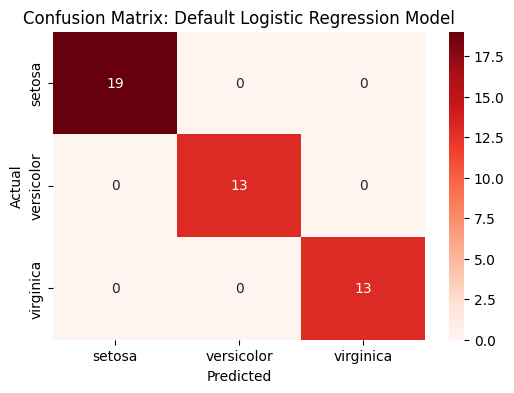

In [7]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Default Logistic Regression Model')
plt.show()

Hyperparameters Tuning

In [8]:
C_values = [0.1, 1, 10]
solvers = ['lbfgs', 'liblinear']
strategies = ['multinomial', 'ovr']

In [9]:
best_score = 0
best_params = {}

In [10]:
from sklearn.multiclass import OneVsRestClassifier

print("Logistic Regression Hyperparameter Tuning Results\n")
for c in C_values:
    for s in solvers:
        for strat in strategies:
            # 'liblinear' does not support 'multinomial', so we handle that exception
            if s == 'liblinear' and strat == 'multinomial':
                continue

            # Initialize Logistic Regression with common parameters
            # The 'multi_class' parameter for 'multinomial' is deprecated and will become default.
            # For 'ovr', OneVsRestClassifier is recommended.

            lr_base = LogisticRegression(C=c, solver=s, max_iter=1000, random_state=42)

            if strat == 'ovr':
                lr = OneVsRestClassifier(lr_base)
            else: # 'multinomial'
                lr = lr_base

            lr.fit(X_train_scaled, y_train)
            y_pred_tune = lr.predict(X_test_scaled)
            score = accuracy_score(y_test, y_pred_tune)

            print(f"C: {c:3} | Solver: {s:9} | Strategy: {strat:11} | Accuracy: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = {'C': c, 'solver': s, 'multi_class': strat}

print(f"\nBest Parameters: {best_params} with Accuracy: {best_score:.4f}")

Logistic Regression Hyperparameter Tuning Results

C: 0.1 | Solver: lbfgs     | Strategy: multinomial | Accuracy: 0.8889
C: 0.1 | Solver: lbfgs     | Strategy: ovr         | Accuracy: 0.8667
C: 0.1 | Solver: liblinear | Strategy: ovr         | Accuracy: 0.8444
C:   1 | Solver: lbfgs     | Strategy: multinomial | Accuracy: 1.0000
C:   1 | Solver: lbfgs     | Strategy: ovr         | Accuracy: 0.9111
C:   1 | Solver: liblinear | Strategy: ovr         | Accuracy: 0.9111
C:  10 | Solver: lbfgs     | Strategy: multinomial | Accuracy: 1.0000
C:  10 | Solver: lbfgs     | Strategy: ovr         | Accuracy: 1.0000
C:  10 | Solver: liblinear | Strategy: ovr         | Accuracy: 0.9556

Best Parameters: {'C': 1, 'solver': 'lbfgs', 'multi_class': 'multinomial'} with Accuracy: 1.0000


In [11]:
# 4. Model Evaluation (Best Model)
best_lr = LogisticRegression(**best_params, max_iter=1000, random_state=42)
best_lr.fit(X_train_scaled, y_train)
y_pred = best_lr.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [12]:
print("Final Logistic Regression Model Evaluation\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Final Logistic Regression Model Evaluation

Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1-Score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



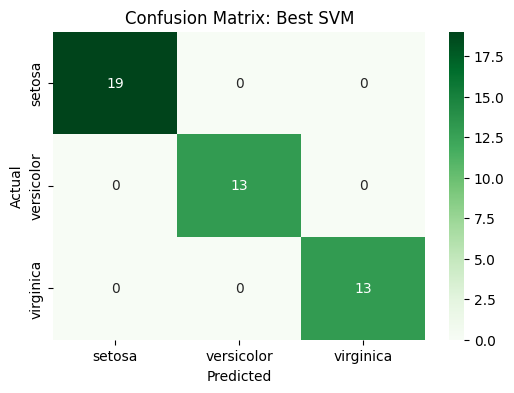

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Best SVM')
plt.show()